## 과제 목표
PyTorch나 TensorFlow와 같은 딥러닝 프레임워크를 전혀 사용하지 않고, 오직 Python과 `NumPy` 행렬 연산만을 이용하여 1-Hidden Layer 인공신경망의 순전파(Forward Propagation)와 역전파(Backpropagation)를 바닥부터 구현합니다. 

이를 통해 가상의 차량 동역학 센서 데이터(속도, 종/횡 가속도, 요레이트)를 3가지 주행 상태(직진, 급제동, 급선회)로 분류하는 모델을 학습시킵니다.

**[구현 지침]**
- `TODO`로 표시된 영역의 코드를 수학적 지식에 기반하여 직접 채워 넣으세요.
- 행렬 곱셈 시 `ValueError: shapes not aligned` 에러가 발생한다면 변수의 `.shape`를 출력하여 차원을 확인하세요.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Toy Dataset 생성 및 확인 (수정 금지)
# ---------------------------------------------------------
def generate_vehicle_data(num_samples=1000):
    np.random.seed(42)
    X, Y = [], []
    for _ in range(num_samples):
        label = np.random.randint(0, 3)
        if label == 0:   # Class 0: 직진/정속
            x = [np.random.rand()*50 + 20, np.random.randn()*0.5, np.random.randn()*0.1, np.random.randn()*0.05]
        elif label == 1: # Class 1: 급제동 (종방향 가속도 음수)
            x = [np.random.rand()*50 + 20, np.random.randn()*2 - 5, np.random.randn()*0.2, np.random.randn()*0.1]
        else:            # Class 2: 급선회 (횡방향 가속도 및 요레이트 증가)
            x = [np.random.rand()*30 + 10, np.random.randn()*0.5, np.random.randn()*3 + 2, np.random.randn()*1.5 + 0.5]
        X.append(x)
        Y.append(label)

    X = np.array(X)
    Y = np.array(Y)

    # Standard Normalization
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return X, Y

X_train, Y_train = generate_vehicle_data(800)
X_test, Y_test = generate_vehicle_data(200)

output_size = 3
Y_train_one_hot = np.eye(output_size)[Y_train]

print(f"Train Data Shape: {X_train.shape}, Train Label Shape: {Y_train_one_hot.shape}")

Train Data Shape: (800, 4), Train Label Shape: (800, 3)


### 1. 파라미터 초기화
네트워크의 가중치($W$)와 편향($b$)을 초기화합니다. 각 행렬의 차원(Shape)이 어떻게 구성되어야 하는지 명확히 이해하고 코드를 작성하세요.

In [2]:
input_size = X_train.shape[1]
hidden_size = 16
learning_rate = 0.1

# np.random.randn 등을 사용하여 가중치는 작게, 편향은 0으로 초기화합니다.
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

### 2. 모델 학습 루프 (Training Loop)
아래의 빈칸(`TODO`)에 순전파, 손실 함수 계산, 역전파, 가중치 업데이트 코드를 직접 구현하세요.

Epoch [50/500], Loss: 1.0814
Epoch [100/500], Loss: 0.7950
Epoch [150/500], Loss: 0.4759
Epoch [200/500], Loss: 0.3753
Epoch [250/500], Loss: 0.3293
Epoch [300/500], Loss: 0.2988
Epoch [350/500], Loss: 0.2717
Epoch [400/500], Loss: 0.2457
Epoch [450/500], Loss: 0.2213
Epoch [500/500], Loss: 0.1991


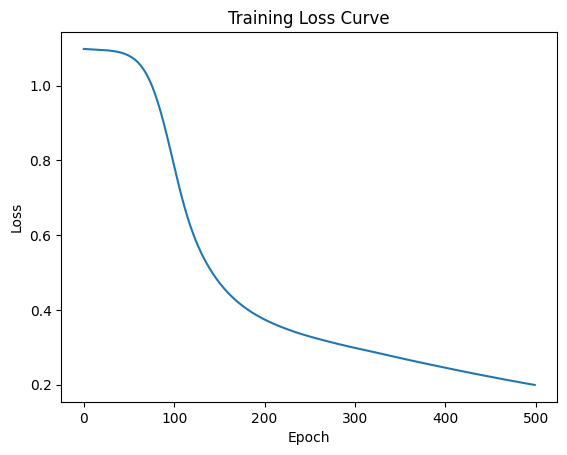

In [5]:
epochs = 500
losses = []
m = X_train.shape[0] # 배치 사이즈

for epoch in range(epochs):
    # ================================================================
    # [TODO 1] 순전파 (Forward Propagation)
    # ================================================================
    Z1 = X_train @ W1 + b1  # (m, hidden_size)
    A1 = np.maximum(0, Z1)  # (ReLU)
    Z2 = A1 @ W2 + b2       # (m, output_size)
    # Softmax (수치 안정성: 행렬 최댓값 빼기)
    Z2_shifted = Z2 - np.max(Z2, axis=1, keepdims=True)
    exp_scores = np.exp(Z2_shifted)
    # probs = ... (Softmax 적용, 수치적 안정성을 위해 Z2의 최댓값을 빼줄 것)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    # pass # 구현 후 pass 삭제

    # ================================================================
    # [TODO 2] 손실 함수 (Cross Entropy Loss)
    # 수식 참고: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss
    # 구현 참고: https://github.com/pytorch/pytorch/blob/874a17dc2ad591c8f23d61e13b3ef2f8e995afa8/aten/src/ATen/native/LossNLL.cpp#L498
    # ================================================================
    # log(0)으로 인한 NaN 발생을 막기 위해 아주 작은 값(1e-8)을 더해줍니다.
    loss = -np.sum(Y_train_one_hot * np.log(probs + 1e-8)) / m
    losses.append(loss)
    # pass # 구현 후 pass 삭제

    # ================================================================
    # [TODO 3] 역전파 (Backward Propagation)
    # ================================================================
    # step1: dZ2 (Softmax + CrossEntropy의 gradient)
    dZ2 = (probs - Y_train_one_hot) / m
    # step2: dW2, db2 (출력층 파라미터)
    dW2 = A1.T @ dZ2        # shape: (hidden_size, output_size) = (16, 3)
    db2 = np.sum(dZ2, axis=0)  # shape: 1, output_size) = (1, 3)
    # step3: dA1, dZ1 (히든층으로 역전파)
    dA1 = dZ2 @ W2.T        # shape: (800, 16)
    dZ1 = dA1 * (Z1 > 0)    # (ReLU 미분 반영)
    # step4: dW1, db1 (입력층 파라미터)
    dW1 = X_train.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    # pass # 구현 후 pass 삭제

    # ================================================================
    # [TODO 4] 가중치 업데이트 (Gradient Descent)
    # ================================================================
    # W1, b1, W2, b2 업데이트
    W1 -= learning_rate * dW1 
    b1 -= learning_rate * db1 
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    # pass # 구현 후 pass 삭제

    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}') # loss 변수가 정상적으로 계산되어야 출력됨

# 학습 곡선 시각화
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### 3. 평가 및 시각화 (Evaluation & Visualization)
학습이 끝난 모델을 바탕으로 전체 데이터(Train+Test)에 대한 추론을 진행하고, 모델이 데이터를 올바르게 군집화했는지 시각적으로 확인합니다. 데이터가 4차원이므로, 가장 특징적인 두 축(종방향 가속도, 요레이트)을 기준으로 2D 산점도(Scatter plot)를 그립니다.

Overall Accuracy: 91.70%



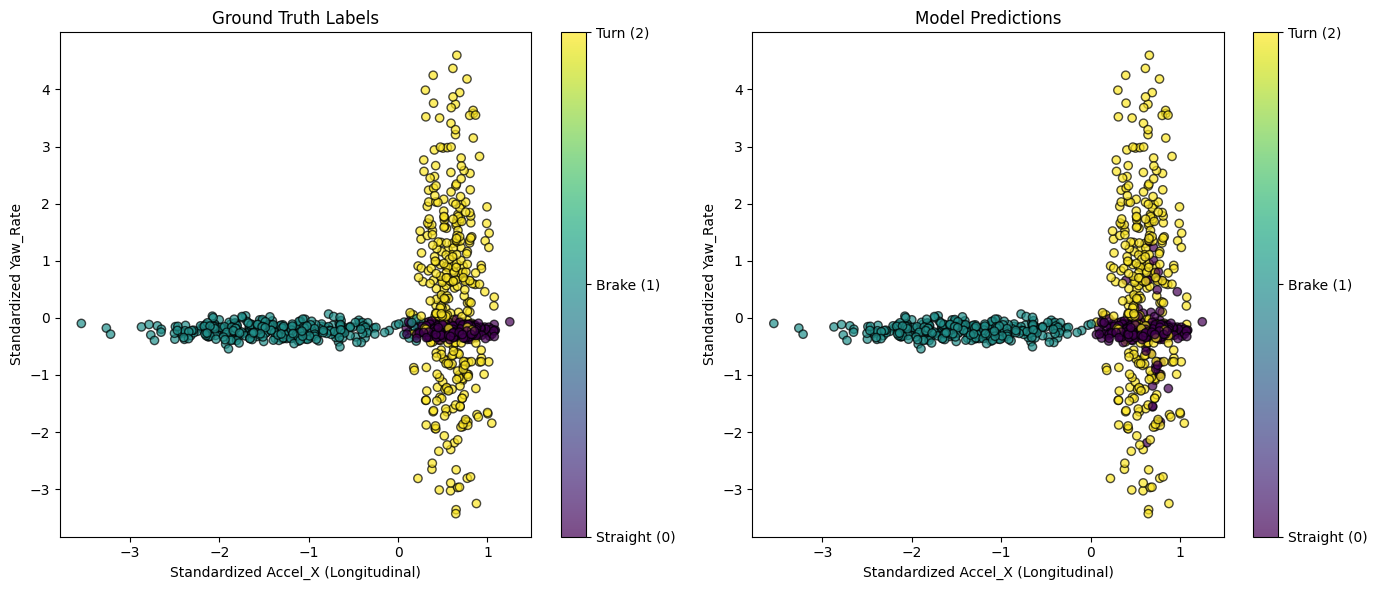

In [6]:
# ---------------------------------------------------------
# 모델 추론 (전체 데이터 대상)
# ---------------------------------------------------------
X_all = np.vstack((X_train, X_test))
Y_all = np.concatenate((Y_train, Y_test))

# 학습된 W, b를 사용하여 전체 데이터셋 Forward Pass
Z1_all = X_all @ W1 + b1
A1_all = np.maximum(0, Z1_all)
Z2_all = A1_all @ W2 + b2
predictions_all = np.argmax(Z2_all, axis=1)

# 정확도 계산
accuracy = np.mean(predictions_all == Y_all)
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# ---------------------------------------------------------
# 결과 시각화
# ---------------------------------------------------------
# 시각화를 위해 4차원 특징 중 2개(Index 1: Accel_X, Index 3: Yaw_Rate)를 선택
feat_x_idx = 1
feat_y_idx = 3

plt.figure(figsize=(14, 6))

# 왼쪽: Ground Truth
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_all[:, feat_x_idx], X_all[:, feat_y_idx],
                       c=Y_all, cmap='viridis', alpha=0.7, edgecolors='k')
plt.title('Ground Truth Labels')
plt.xlabel('Standardized Accel_X (Longitudinal)')
plt.ylabel('Standardized Yaw_Rate')
cbar1 = plt.colorbar(scatter1, ticks=[0, 1, 2])
cbar1.ax.set_yticklabels(['Straight (0)', 'Brake (1)', 'Turn (2)'])

# 오른쪽: Model Predictions
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_all[:, feat_x_idx], X_all[:, feat_y_idx],
                       c=predictions_all, cmap='viridis', alpha=0.7, edgecolors='k')
plt.title('Model Predictions')
plt.xlabel('Standardized Accel_X (Longitudinal)')
plt.ylabel('Standardized Yaw_Rate')
cbar2 = plt.colorbar(scatter2, ticks=[0, 1, 2])
cbar2.ax.set_yticklabels(['Straight (0)', 'Brake (1)', 'Turn (2)'])

plt.tight_layout()
plt.show()